# Module 1 — Language Detection

**Goal:** build a multi-class classifier that identifies the language of each customer message,
so the system can reply in the same language and route correctly.

**Data:** [papluca/language-identification](https://huggingface.co/datasets/papluca/language-identification)
(90k samples, 20 languages, pre-split train / validation / test).

**Method (traditional NLP):**
1. **Text cleaning** — lowercase, strip URLs / e-mails / mentions / numbers (masked as `<num>`),
   keep the letters of *every* script (Arabic, Cyrillic, Greek, Thai, Japanese, ...).
2. **Feature engineering** — *character n-grams (2..5)* with TF-IDF weighting. Char n-grams capture
   language-specific morphology and script statistics far better than words for short, noisy chat text.
3. **Model** — linear logistic regression (fast, interpretable, strong for high-dim sparse text).

**Enhancements (per the assignment):**
- Confidence threshold → low-confidence predictions flagged as `unknown` (graceful degradation).
- Per-language F1 report + confusion matrix.
- Unicode-aware cleaning so non-Latin scripts are not destroyed by an ASCII-only regex.


In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path('..').resolve()))

import pandas as pd
import numpy as np
from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from src.preprocessing import normalize_text
from src.config import LANG_DIR, LANG_CONFIDENCE_THRESHOLD
import warnings
warnings.filterwarnings('ignore')


In [2]:
ds = load_dataset('papluca/language-identification')
def build_df(split):
    df = pd.DataFrame({'text': split['text'], 'label': split['labels']})
    df['clean'] = df['text'].apply(lambda x: normalize_text(x, keep_chars=True))
    return df
train_df, val_df, test_df = build_df(ds['train']), build_df(ds['validation']), build_df(ds['test'])
print(f'Train={len(train_df):,}  Val={len(val_df):,}  Test={len(test_df):,}  languages={train_df["label"].nunique()}')
print('Cleaned sample:', repr(train_df['clean'].iloc[0][:120]))

Train=70,000  Val=10,000  Test=10,000  languages=20
Cleaned sample: 'os chefes de defesa da estónia letónia lituânia alemanha itália espanha e eslováquia assinarão o acordo para fornecer pe'


In [3]:
vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 5), min_df=2, sublinear_tf=True)
X_train = vectorizer.fit_transform(train_df['clean'])
X_val, X_test = vectorizer.transform(val_df['clean']), vectorizer.transform(test_df['clean'])
y_train, y_val, y_test = train_df['label'], val_df['label'], test_df['label']
print('Training matrix:', X_train.shape, '| features = char n-grams')
feats = vectorizer.get_feature_names_out()
print('Example features:', list(feats[:8]))

Training matrix: (70000, 491150) | features = char n-grams


Example features: [' _', ' _ ', ' a', ' a ', ' aa', ' aa ', ' aaa', ' aaa ']


In [4]:
model = LogisticRegression(C=1.0, max_iter=2000, solver='lbfgs')
model.fit(X_train, y_train)
for name, X, y in [('val', X_val, y_val), ('test', X_test, y_test)]:
    preds = model.predict(X)
    print(f'[{name}] accuracy = {accuracy_score(y, preds):.4f}')
print(classification_report(y_test, model.predict(X_test), zero_division=0))

[val] accuracy = 0.9947
[test] accuracy = 0.9949


              precision    recall  f1-score   support

          ar       1.00      1.00      1.00       500
          bg       1.00      1.00      1.00       500
          de       1.00      1.00      1.00       500
          el       1.00      1.00      1.00       500
          en       1.00      1.00      1.00       500
          es       0.99      1.00      1.00       500
          fr       1.00      1.00      1.00       500
          hi       1.00      0.97      0.98       500
          it       1.00      1.00      1.00       500
          ja       1.00      1.00      1.00       500
          nl       1.00      1.00      1.00       500
          pl       1.00      1.00      1.00       500
          pt       0.99      0.99      0.99       500
          ru       1.00      1.00      1.00       500
          sw       0.94      1.00      0.97       500
          th       1.00      1.00      1.00       500
          tr       1.00      1.00      1.00       500
          ur       1.00    

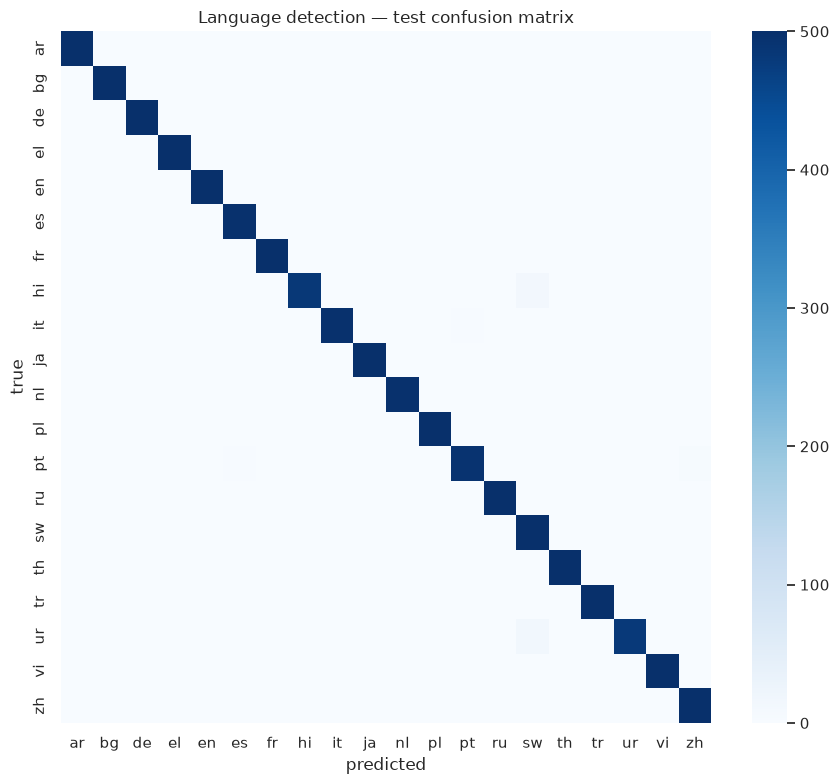

Unknown-flagging rate (conf<0.6): 2.83%


In [5]:
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()
proba = model.predict_proba(X_test)
conf = proba.max(axis=1)
cm = confusion_matrix(y_test, model.predict(X_test), labels=model.classes_)
plt.figure(figsize=(9, 8))
sns.heatmap(cm, xticklabels=model.classes_, yticklabels=model.classes_, annot=False, cmap='Blues')
plt.title('Language detection — test confusion matrix')
plt.xlabel('predicted'); plt.ylabel('true')
plt.tight_layout()
plt.show()
unknown_rate = (conf < LANG_CONFIDENCE_THRESHOLD).mean()
print('Unknown-flagging rate (conf<0.6):', f'{unknown_rate:.2%}')

In [6]:
cm_low = (conf < LANG_CONFIDENCE_THRESHOLD)
df_low = test_df[cm_low]
print('Examples the model is unsure about (flagged unknown):')
for _, r in df_low.head(4).iterrows():
    print('  ', repr(r['text'][:70]), '->', r['label'])

Examples the model is unsure about (flagged unknown):
   'Debutta Apple iPad mini' -> it
   'Szympans kopie cel.' -> pl
   "L'orso panda giaceva sui tronchi." -> it
   'Captain Blood เห็นความคิดของพวกเขาในเสี้ยววินาที' -> th


In [7]:
from src.models.language import LanguageDetector
detector = LanguageDetector()
probes = ['I want a refund for my broken headphones', 'Soyez rapide, mon colis est en retard',
          'مطلوب استرداد المبلغ بسرعة', 'Пожалуйста, отмените мой заказ', '주문 상태를 알려주세요',
          'Ich brauche Hilfe bei meiner Rechnung']
for p in probes:
    r = detector.detect(p)
    print(f'{r["language"]:8s} (conf={r["confidence"]:.2f})  {p}')
print('\nArtifacts saved to', LANG_DIR)

en       (conf=0.78)  I want a refund for my broken headphones
fr       (conf=0.62)  Soyez rapide, mon colis est en retard
ar       (conf=0.68)  مطلوب استرداد المبلغ بسرعة
unknown  (conf=0.49)  Пожалуйста, отмените мой заказ
unknown  (conf=0.32)  주문 상태를 알려주세요
de       (conf=0.78)  Ich brauche Hilfe bei meiner Rechnung

Artifacts saved to /media/mosaab/01DC3BA86FD6B9C0/Projects/ITI/NLP/project/artifacts/language
